In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import json
import sys

model_paths = [
    "/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/8",
    "",
]

for p in model_paths:
    if Path(p).exists():
        sys.path.insert(0, p)
        break

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))


/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/8/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("/kaggle/working")
if not work_dir.exists():
    work_dir = Path(".")

out_dir = work_dir / "results_exp_10_convection1d_large_lbfgs"
out_dir.mkdir(parents=True, exist_ok=True)

print("device:", device)
print("work_dir:", work_dir)
print("out_dir:", out_dir)


torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda
work_dir: /kaggle/working
out_dir: /kaggle/working/results_exp_10_convection1d_large_lbfgs


In [3]:
beta_values = [30.0, 50.0]
dtype_values = ["fp32", "fp64"]
seed_values = [0]

variants = [
    {
        "variant": "lbfgs_grid_t4",
        "adam_steps": 0,
        "lbfgs_steps": 4000,
        "lbfgs_max_iter": 10,
        "lbfgs_max_eval": None,
        "lbfgs_lr": 1.0,
        "lbfgs_history_size": 50,
        "lbfgs_tolerance_grad": 1e-8,
        "lbfgs_tolerance_change": 1e-9,
        "lbfgs_line_search_fn": "strong_wolfe",
        "resample_every": 0,
        "point_mode": "grid",
        "n_grid": 65,
        "hid_size": 256,
        "num_layers": 3,
        "init_gain": 1.0,
    },
]

runs = []
i = 1
for beta in beta_values:
    for variant in variants:
        for dtype in dtype_values:
            for seed in seed_values:
                row = variant.copy()
                row["run_id"] = i
                row["beta"] = beta
                row["dtype"] = dtype
                row["seed"] = seed
                row["n_collocation"] = row["n_grid"] * row["n_grid"]
                row["n_ic"] = row["n_grid"]
                row["n_bc"] = row["n_grid"]
                runs.append(row)
                i += 1

pd.DataFrame(runs)


,variant,adam_steps,lbfgs_steps,lbfgs_max_iter,lbfgs_max_eval,lbfgs_lr,lbfgs_history_size,lbfgs_tolerance_grad,lbfgs_tolerance_change,lbfgs_line_search_fn,...,hid_size,num_layers,init_gain,run_id,beta,dtype,seed,n_collocation,n_ic,n_bc
0,lbfgs_grid_t4,0,4000,10,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,...,256,3,1.0,1,30.0,fp32,0,4225,65,65
1,lbfgs_grid_t4,0,4000,10,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,...,256,3,1.0,2,30.0,fp64,0,4225,65,65
2,lbfgs_grid_t4,0,4000,10,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,...,256,3,1.0,3,50.0,fp32,0,4225,65,65
3,lbfgs_grid_t4,0,4000,10,None,1.0,50,1.000000e-08,1.000000e-09,strong_wolfe,...,256,3,1.0,4,50.0,fp64,0,4225,65,65


In [4]:
base_config = {
    "task_name": "convection1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "beta": 50.0,
    "hid_size": 256,
    "num_layers": 3,
    "init_gain": 1.0,
    "n_collocation": 65 * 65,
    "n_ic": 65,
    "n_bc": 65,
    "point_mode": "grid",
    "adam_steps": 0,
    "lbfgs_steps": 4000,
    "lr_adam": 1e-3,
    "resample_every": 0,
    "use_adam": False,
    "use_lbfgs": True,
    "lbfgs_tolerance_grad": 1e-8,
    "lbfgs_tolerance_change": 1e-9,
    "lbfgs_history_size": 50,
    "lbfgs_lr": 1.0,
    "lbfgs_max_iter": 10,
    "lbfgs_max_eval": None,
    "lbfgs_line_search_fn": "strong_wolfe",
    "log_dir": str(out_dir / "runs" / "convection_large_lbfgs_tmp"),
}

pd.DataFrame(runs).groupby(["beta", "variant", "dtype"]).size()


beta  variant        dtype
30.0  lbfgs_grid_t4  fp32     1
                     fp64     1
50.0  lbfgs_grid_t4  fp32     1
                     fp64     1
dtype: int64

In [5]:
all_summaries = []
all_histories = {}

for run in runs:
    config = base_config.copy()
    config.update(run)
    config["use_adam"] = config["adam_steps"] > 0
    config["use_lbfgs"] = config["lbfgs_steps"] > 0
    name = f"exp10_r{run['run_id']:03d}_beta{str(run['beta']).replace('.', 'p')}_{run['variant']}_{run['dtype']}_s{run['seed']}"
    config["log_dir"] = str(out_dir / "runs" / name)

    run_dir = Path(config["log_dir"])
    summary_file = run_dir / "summary.json"
    metrics_file = run_dir / "metrics.csv"

    if summary_file.exists() and metrics_file.exists():
        with open(summary_file) as f:
            summary = json.load(f)
        history = pd.read_csv(metrics_file)
    else:
        history, summary = pinn_model.run_experiment(config)

    best = history.loc[history["l2_error"].idxmin()]
    summary["run_id"] = run["run_id"]
    summary["variant"] = run["variant"]
    summary["beta"] = run["beta"]
    summary["seed"] = run["seed"]
    summary["n_grid"] = run["n_grid"]
    summary["adam_steps_config"] = run["adam_steps"]
    summary["lbfgs_steps_config"] = run["lbfgs_steps"]
    summary["lbfgs_max_iter"] = run["lbfgs_max_iter"]
    summary["lbfgs_max_eval"] = run["lbfgs_max_eval"]
    summary["lbfgs_history_size"] = run["lbfgs_history_size"]
    summary["lbfgs_tolerance_grad"] = run["lbfgs_tolerance_grad"]
    summary["lbfgs_tolerance_change"] = run["lbfgs_tolerance_change"]
    summary["resample_every"] = run["resample_every"]
    summary["point_mode"] = run["point_mode"]
    summary["lbfgs_lr"] = run["lbfgs_lr"]
    summary["n_collocation"] = run["n_collocation"]
    summary["n_ic"] = run["n_ic"]
    summary["n_bc"] = run["n_bc"]
    summary["hid_size"] = run["hid_size"]
    summary["num_layers"] = run["num_layers"]
    summary["init_gain"] = run["init_gain"]
    summary["best_l2_error"] = float(best["l2_error"])
    summary["best_step"] = int(best["step"])
    summary["l2_ratio"] = float(summary["final_l2_error"] / summary["best_l2_error"])

    all_summaries.append(summary)
    all_histories[name] = history

    print(run["run_id"], run["variant"], "beta", run["beta"], run["dtype"], "seed", run["seed"], "final", summary["final_l2_error"], "best", summary["best_l2_error"], "time", summary["time_sec"])


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1 lbfgs_grid_t4 beta 30.0 fp32 seed 0 final 0.006611044984310865 best 0.006611044984310865 time 391.45881175994873
2 lbfgs_grid_t4 beta 30.0 fp64 seed 0 final 0.0104210207454427 best 0.010180578926038839 time 1364.334602355957
3 lbfgs_grid_t4 beta 50.0 fp32 seed 0 final 0.8505832552909851 best 0.8505832552909851 time 403.3929817676544
4 lbfgs_grid_t4 beta 50.0 fp64 seed 0 final 1.885598995013883 best 0.8581250754380461 time 1701.893218755722


In [6]:
df = pd.DataFrame(all_summaries)
cols = [
    "run_id", "variant", "task_name", "beta", "dtype", "seed",
    "hid_size", "num_layers", "init_gain", "n_grid", "n_collocation", "n_ic", "n_bc", "point_mode",
    "adam_steps_config", "lbfgs_steps_config", "lbfgs_max_iter", "lbfgs_max_eval",
    "lbfgs_history_size", "lbfgs_tolerance_grad", "lbfgs_tolerance_change",
    "resample_every", "lbfgs_lr",
    "final_loss", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "time_sec", "log_dir",
]
df = df[cols]
df.to_csv(out_dir / "exp_10_convection1d_large_lbfgs_summary.csv", index=False)
df.sort_values("best_l2_error")


,run_id,variant,task_name,beta,dtype,seed,hid_size,num_layers,init_gain,n_grid,...,lbfgs_tolerance_change,resample_every,lbfgs_lr,final_loss,final_l2_error,best_l2_error,best_step,l2_ratio,time_sec,log_dir
0,1,lbfgs_grid_t4,convection1d,30.0,fp32,0,256,3,1.0,65,...,1.000000e-09,0,1.0,0.000039,0.006611,0.006611,1100,1.000000,391.458812,/kaggle/working/results_exp_10_convection1d_la...
1,2,lbfgs_grid_t4,convection1d,30.0,fp64,0,256,3,1.0,65,...,1.000000e-09,0,1.0,0.000019,0.010421,0.010181,1500,1.023618,1364.334602,/kaggle/working/results_exp_10_convection1d_la...
2,3,lbfgs_grid_t4,convection1d,50.0,fp32,0,256,3,1.0,65,...,1.000000e-09,0,1.0,0.017538,0.850583,0.850583,900,1.000000,403.392982,/kaggle/working/results_exp_10_convection1d_la...
3,4,lbfgs_grid_t4,convection1d,50.0,fp64,0,256,3,1.0,65,...,1.000000e-09,0,1.0,0.000031,1.885599,0.858125,1000,2.197348,1701.893219,/kaggle/working/results_exp_10_convection1d_la...


In [7]:
grouped = df.groupby(["variant", "beta", "dtype"]).agg(
    best_l2_median=("best_l2_error", "median"),
    best_l2_min=("best_l2_error", "min"),
    final_l2_median=("final_l2_error", "median"),
    ok_1e_2=("best_l2_error", lambda x: float((x < 1e-2).mean())),
    ok_5e_2=("best_l2_error", lambda x: float((x < 5e-2).mean())),
    time_median=("time_sec", "median"),
).reset_index()

grouped.to_csv(out_dir / "exp_10_convection1d_large_lbfgs_grouped.csv", index=False)
grouped.sort_values(["beta", "best_l2_median"])


,variant,beta,dtype,best_l2_median,best_l2_min,final_l2_median,ok_1e_2,ok_5e_2,time_median
0,lbfgs_grid_t4,30.0,fp32,0.006611,0.006611,0.006611,1.0,1.0,391.458812
1,lbfgs_grid_t4,30.0,fp64,0.010181,0.010181,0.010421,0.0,1.0,1364.334602
2,lbfgs_grid_t4,50.0,fp32,0.850583,0.850583,0.850583,0.0,0.0,403.392982
3,lbfgs_grid_t4,50.0,fp64,0.858125,0.858125,1.885599,0.0,0.0,1701.893219


In [8]:
best_pivot = grouped.pivot_table(
    index=["variant", "beta"],
    columns="dtype",
    values="best_l2_median",
    aggfunc="first",
).reset_index()

best_pivot["fp64_over_fp32"] = best_pivot["fp64"] / best_pivot["fp32"]
best_pivot.to_csv(out_dir / "exp_10_convection1d_large_lbfgs_fp64_ratio.csv", index=False)
best_pivot.sort_values("fp64_over_fp32")


dtype,variant,beta,fp32,fp64,fp64_over_fp32
1,lbfgs_grid_t4,50.0,0.850583,0.858125,1.008867
0,lbfgs_grid_t4,30.0,0.006611,0.010181,1.539935


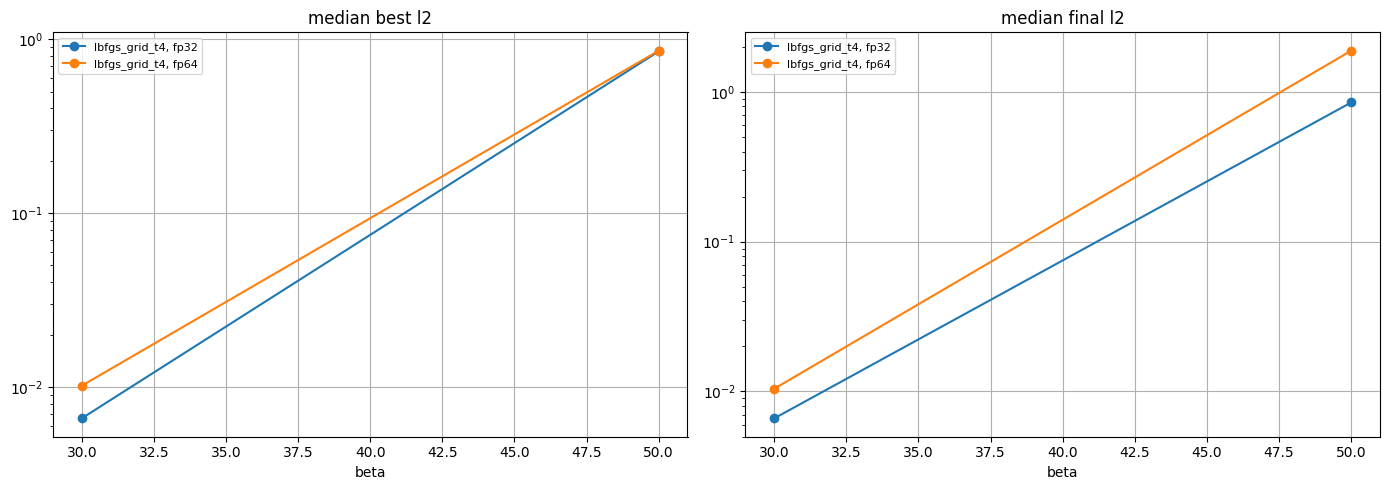

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for variant in grouped["variant"].unique():
    for dtype in dtype_values:
        cur = grouped[(grouped["variant"] == variant) & (grouped["dtype"] == dtype)].sort_values("beta")
        if len(cur) == 0:
            continue
        label = f"{variant}, {dtype}"
        ax[0].plot(cur["beta"], cur["best_l2_median"], marker="o", label=label)
        ax[1].plot(cur["beta"], cur["final_l2_median"], marker="o", label=label)

ax[0].set_title("median best l2")
ax[1].set_title("median final l2")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
for a in ax:
    a.set_xlabel("beta")
    a.grid(True)
    a.legend(fontsize=8)

fig.tight_layout()
plt.show()


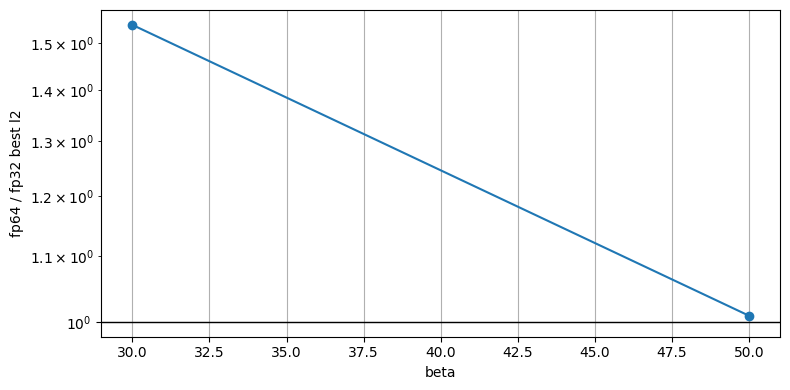

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
cur = best_pivot.sort_values("beta")
ax.plot(cur["beta"], cur["fp64_over_fp32"], marker="o")
ax.axhline(1.0, color="black", linewidth=1)
ax.set_xlabel("beta")
ax.set_ylabel("fp64 / fp32 best l2")
ax.set_yscale("log")
ax.grid(True)
fig.tight_layout()
plt.show()


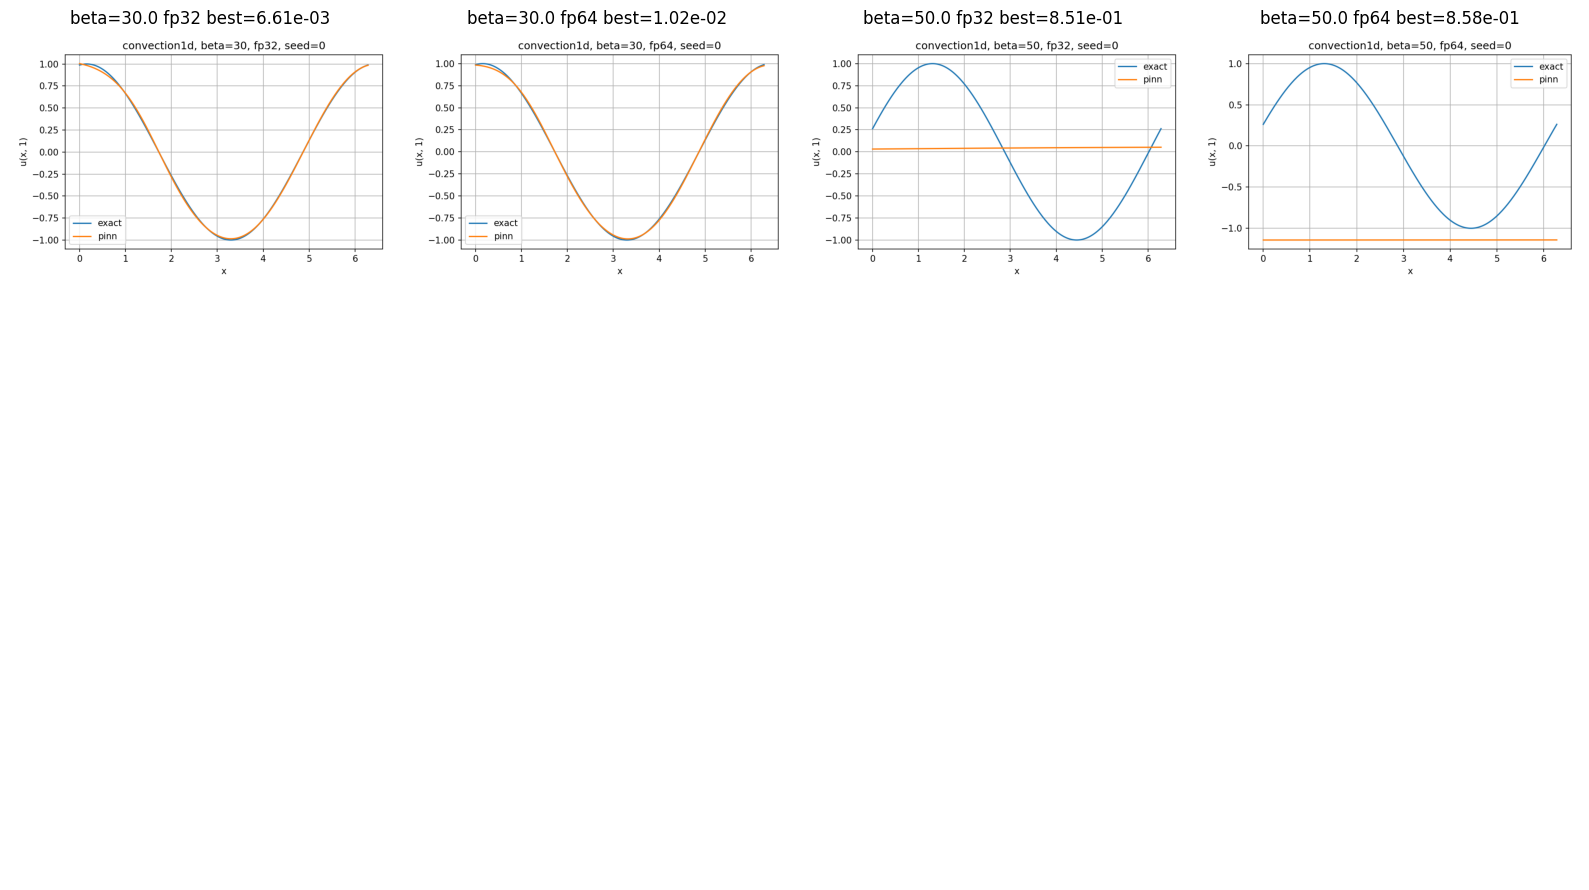

In [11]:
show = df.sort_values("best_l2_error").head(12)
rows = 3
cols = 4
fig, ax = plt.subplots(rows, cols, figsize=(16, 9))
ax = np.array(ax).reshape(rows, cols)

for k in range(rows * cols):
    r = k // cols
    c = k % cols
    ax[r, c].axis("off")
    if k >= len(show):
        continue
    row = show.iloc[k]
    p = Path(row["log_dir"]) / "solution_t1.png"
    ax[r, c].set_title(f"beta={row['beta']} {row['dtype']} best={row['best_l2_error']:.2e}")
    if p.exists():
        img = plt.imread(p)
        ax[r, c].imshow(img)

fig.tight_layout()
plt.show()


In [12]:
bad = df.sort_values("best_l2_error", ascending=False).head(12)
bad[["variant", "beta", "dtype", "seed", "final_l2_error", "best_l2_error", "best_step", "l2_ratio", "log_dir"]]


,variant,beta,dtype,seed,final_l2_error,best_l2_error,best_step,l2_ratio,log_dir
3,lbfgs_grid_t4,50.0,fp64,0,1.885599,0.858125,1000,2.197348,/kaggle/working/results_exp_10_convection1d_la...
2,lbfgs_grid_t4,50.0,fp32,0,0.850583,0.850583,900,1.000000,/kaggle/working/results_exp_10_convection1d_la...
1,lbfgs_grid_t4,30.0,fp64,0,0.010421,0.010181,1500,1.023618,/kaggle/working/results_exp_10_convection1d_la...
0,lbfgs_grid_t4,30.0,fp32,0,0.006611,0.006611,1100,1.000000,/kaggle/working/results_exp_10_convection1d_la...
